### Cart Pole Function Approximation

Cartpole is a pendulum with a center of gravity above its pivot point. It’s unstable, but can be controlled by moving the pivot point under the center of mass. The goal is to keep the cartpole balanced by applying appropriate forces to a pivot point.

![Cart Pole](https://miro.medium.com/v2/resize:fit:532/format:webp/1*wRLArpx5VjWZWPeyf7H8Gw.png)

Actions:

0: Push cart to the left

1: Push cart to the right

The state of the system can be described by four variables: the position of the cart, the velocity of the cart, the angle of the pole, and the rotation rate of the pole.

Since the goal is to keep the pole upright for as long as possible, the control agent receives a reward of +1 for every step taken, including the termination step. The threshold for rewards is 500 for v1 and 200 for v0. Episodes terminate if the state values are above certain thresholds (pole is nearly down!).

See also https://gymnasium.farama.org/environments/classic_control/cart_pole/

### Polynomial Regression in Linear Function Approximation

Polynomial regression is a form of linear function approximation where we model our predictions as a linear combination of polynomial features of the input. Despite involving polynomials, it's still considered *linear* because the linearity refers to the coefficients (or weights) of the model, not the degree of the input features.

**Idea:** transform our input data (say state variables $x$ and $y$) into polynomial terms (like
$$1, x,y,xy,x^2, y^2 $$
etc.) and then apply a linear model to these transformed features. This method allows us to capture more complex relationships in data compared to simple linear regression, while still maintaining the computational simplicity of linear models. For example, a model with features $1,x,y,xy,x^2, y^2$ would have the form $$  w_0+w_1x +w_2y+ w_3 xy+w_4x^2+w_5 y^2 ,$$ which is linear in terms of weights $w_0$, ..., $w_5$.


**Why using polynomial regression for CartPole?**

The dynamics of the CartPole are inherently non-linear. The relationship between the pole's angle, the cart's position, and the subsequent state after taking an action cannot be easily captured by a simple linear model.

**What polynomial feature shall we use?**

Polynomial features (like the product of the angle of the pole and velocity of the cart) can capture the complexity of the system's dynamics better than a linear function of the raw state variables.

In [14]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
#from gym.wrappers import RecordVideo
from IPython.display import clear_output

# Create the CartPole environment
env = gym.make('CartPole-v1', render_mode='rgb_array')

# hard-coded normalization values
normalization_factors = [2,3,0.2,3.3]

# todo: remove correlated features!
def extract_polynomial_features(state, action):
    # normalization
    state_values = np.divide(list(state), normalization_factors)
    # Include action and state information as a part of the features
    # action features = [action, 1-action]
    # state features = state_values
    values = [action, 1-action] + list(state_values)
    # include "1" so that the polynomial has an offset
    features = [1] + values
    for i in range(len(values)):
        for j in range(len(values)):
          # added this condition to remove correlated features
          if (i == j):
            continue
          ## consider polynomial state features
          features.append(values[i] * values[j])
    return np.array(features)

def approximate_value(state, action, weights):
    # Linear approximation of value function with action features
    features = extract_polynomial_features(state, action)
    return np.dot(weights, features)

def choose_action(state, weights, epsilon=0.1):
    # Random exploration with probability epsilon
    if np.random.rand() < epsilon:
        return np.random.choice([0, 1])  # Randomly choose 0 (left) or 1 (right)
    else:
        # Exploitation: choose the best estimated action
        value_if_left = approximate_value(state, 0, weights)
        value_if_right = approximate_value(state, 1, weights)
        return 0 if value_if_left > value_if_right else 1

# Number of features, hard-coded, see function extract_polynomial_features
num_features = 1 + 6*6  # changed from 1 + 6 + 6*6

# initialize the weights (not randomly)
#weights = np.random.randn(num_features)
weights = np.zeros(num_features)
weights[0] = 1  # Set bias to 1 to give each (state, action) an initial value of 1

num_episodes = 5000
learning_rate = 0.05

gamma = 1

# average over a number of gradients to decrease high variance
mini_batch_size = 20   # Size of the mini-batch for SGD


# Initialize variables for mini-batch SGD
cumulative_gradients = np.zeros_like(weights)
update_count = 0

# to check agent's performance

episode_lengths = []


# Training loop
for episode in range(num_episodes):

    state = env.reset()[0]
    done = False
    truncated = False
    step_count = 0
    while not (done or truncated):

        action = choose_action(state, weights)
        next_state, reward, done, truncated,_ = env.step(action)


        # use Q-learning (A_{t+1} is next best action)
        if not (done or truncated):
            # Choose the action in the next state with the highest estimated value
            best_next_action = 0 if approximate_value(next_state, 0, weights) > approximate_value(next_state, 1, weights) else 1
            target = reward + gamma * approximate_value(next_state, best_next_action, weights)
        else:
            target = reward

        # Accumulate gradients for mini-batch SGD
        features = extract_polynomial_features(state, action)
        gradients = learning_rate * (target - approximate_value(state, action, weights)) * features
        cumulative_gradients += gradients

        # Update weights - only every ... steps
        update_count += 1
        if update_count % mini_batch_size == 0:
            weights += cumulative_gradients / mini_batch_size
            # reset weights
            cumulative_gradients = np.zeros_like(weights)

        step_count += 1

        state = next_state

    # store episode length for statistics
    episode_lengths.append(step_count)

    if episode % 100 == 0:
        # Print episode length statistics
        average_length = np.mean(episode_lengths[-200:])  # Average over last 200 episodes
        print(f"Episode: {episode}, Average Length: {average_length}")


Episode: 0, Average Length: 9.0
Episode: 100, Average Length: 9.693069306930694
Episode: 200, Average Length: 9.775
Episode: 300, Average Length: 9.875
Episode: 400, Average Length: 9.9
Episode: 500, Average Length: 9.905
Episode: 600, Average Length: 10.105
Episode: 700, Average Length: 10.515
Episode: 800, Average Length: 128.955
Episode: 900, Average Length: 201.075
Episode: 1000, Average Length: 87.405
Episode: 1100, Average Length: 17.105
Episode: 1200, Average Length: 113.615
Episode: 1300, Average Length: 158.195
Episode: 1400, Average Length: 70.33
Episode: 1500, Average Length: 105.425
Episode: 1600, Average Length: 130.915
Episode: 1700, Average Length: 87.415
Episode: 1800, Average Length: 99.44
Episode: 1900, Average Length: 145.24
Episode: 2000, Average Length: 104.975
Episode: 2100, Average Length: 85.62
Episode: 2200, Average Length: 135.43
Episode: 2300, Average Length: 100.35
Episode: 2400, Average Length: 45.485
Episode: 2500, Average Length: 86.555
Episode: 2600, Ave

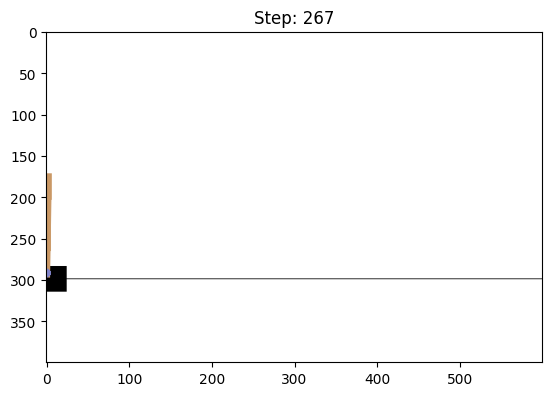

In [2]:
# plot last episode (with epsilon =0 )
state = env.reset()[0]
done = False
truncated = False

clear_output(wait=True)
plt.imshow(env.render())
plt.show()
plt.pause(0.01)
step=0

while not (done or truncated):
    action = choose_action(state, weights, epsilon = 0.0)
    next_state, reward, done, truncated,_ = env.step(action)
    plt.title(f'Step: {step}')
    step +=1
    clear_output(wait=True)
    plt.imshow(env.render())
    plt.show()
    plt.pause(0.01)
    state = next_state



In [6]:
# initialize vectors for finding max/min values
min_vals = np.array([np.inf, np.inf, np.inf, np.inf])
max_vals = np.array([-1*np.inf, -1*np.inf, -1*np.inf, -1*np.inf])


# find out max and min values of the features (we do not trust in the values given by Gymnasium)
for i, x in enumerate(list(state)):
  if x < min_vals[i]:
    min_vals[i] = x
  if x > max_vals[i]:
    max_vals[i] = x




normalization_factors = [2,3,0.2,3.3]
print(max_vals)
print(normalization_factors)
print(np.divide(max_vals, normalization_factors))

[-2.40067124e+00 -7.01811492e-01  9.46894288e-03 -8.87294183e-04]
[2, 3, 0.2, 3.3]
[-1.20033562e+00 -2.33937164e-01  4.73447144e-02 -2.68877025e-04]


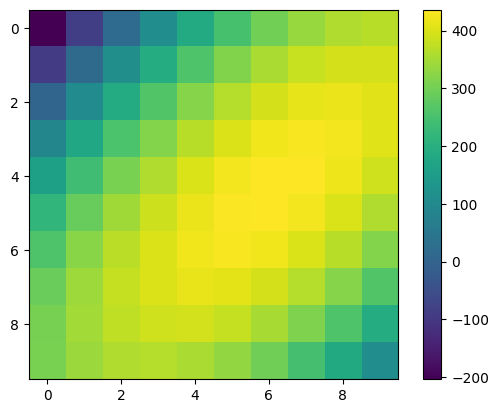

In [7]:
X = np.zeros([10,10])
for i,pos in enumerate(np.arange(-2,2,0.4)):
    for j, velo in enumerate(np.arange(-5,5,1)):
        X[i,j] = approximate_value((pos,
                                    velo,
                                    0,  # angle
                                    0), # ang velocity
                                   0,  # Action left
                                   weights)
plt.imshow(X, cmap='viridis')  # 'cmap' specifies the colormap
plt.colorbar()  # Optionally add a color bar
plt.show()

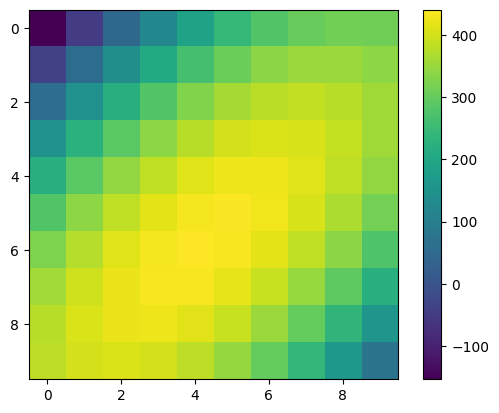

In [8]:
Y = np.zeros([10,10])
for i,pos in enumerate(np.arange(-2,2,0.4)):
    for j, velo in enumerate(np.arange(-5,5,1)):
        Y[i,j] = approximate_value((pos,
                                    velo,
                                    0,  # angle
                                    0), # ang velocity
                                   1,  # Action right
                                   weights)
plt.imshow(Y, cmap='viridis')  # 'cmap' specifies the colormap
plt.colorbar()  # Optionally add a color bar
plt.show()

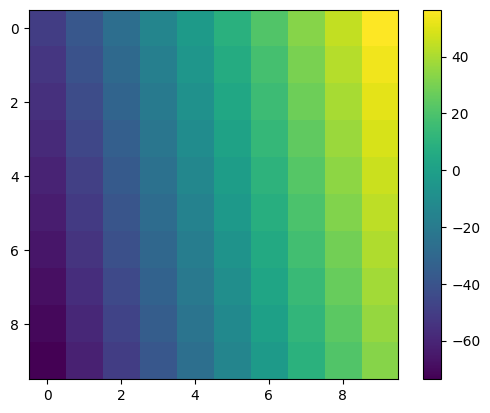

In [9]:
plt.imshow(X-Y, cmap='viridis')  # 'cmap' specifies the colormap
plt.colorbar()  # Optionally add a color bar
plt.show()

In [11]:
def plot_relative_action_values(weights):
    Xl = np.zeros([10,10])
    Xr = np.zeros([10,10])
    for i,pos in enumerate(np.arange(-1,1,0.2)):
        for j, angle in enumerate(np.arange(-1,1,0.2)):
            Xl[i,j] = approximate_value((pos,
                                        0,
                                        angle,  # angle
                                        0), # ang velocity
                                       0,  # Action left
                                       weights)
            Xr[i,j] = approximate_value((pos,
                                        0,
                                        angle,  # angle
                                        0), # ang velocity
                                       1,  # Action left
                                       weights)
    plt.imshow(Xl-Xr, cmap='viridis', extent=[-1, 1, -1, 1])  # 'cmap' specifies the colormap
    plt.colorbar()  # Optionally add a color bar
    plt.show()